In [ ]:
# https://jacobgil.github.io/deeplearning/vision-transformer-explainability
# https://github.com/mashaan14/VisionTransformer-MNIST/blob/main/VisionTransformer_MNIST.ipynb
# https://github.com/jeonsworld/ViT-pytorch/blob/main/visualize_attention_map.ipynb

In [1]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
from dataset import Leaves, collate_fn
from torch.utils.data import Dataset, DataLoader

model = AutoModelForImageClassification.from_pretrained(pretrained_model_name_or_path=r"models\checkpoint-18", attn_implementation="eager")
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

dataset_test = Leaves(processor, csv_path="dataset/annotations.csv", split="test")
dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True)
sample = next(iter(dataloader))


preds = model(sample['pixel_values'], output_attentions=True, return_dict=True)
labels = sample['labels']



c:\ProgramData\anaconda3\envs\py39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


In [2]:
from PIL import Image
import torch
import numpy as np

# Set the path to the image you want to visualize
CONFIG = {"image_path": "path/to/your/image.jpg"}

img = Image.open(CONFIG["image_path"])
img = img.resize((600, 600))
img = np.array(img)

sample = processor(torch.tensor(img), return_tensors="pt")
preds = model(sample['pixel_values'], output_attentions=True, return_dict=True)


In [3]:
preds

ImageClassifierOutput(loss=None, logits=tensor([[-0.2215,  0.7742]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=(tensor([[[[7.7338e-01, 3.3044e-03, 2.3431e-03,  ..., 1.5668e-03,
           1.1158e-03, 1.3725e-03],
          [4.4308e-02, 9.3977e-01, 1.6294e-05,  ..., 2.6309e-06,
           1.1266e-05, 7.2512e-08],
          [6.5552e-01, 1.7816e-04, 2.6641e-01,  ..., 1.7818e-04,
           1.5053e-05, 6.6650e-04],
          ...,
          [1.0689e-07, 3.9785e-12, 1.8534e-11,  ..., 1.0000e+00,
           1.2926e-10, 5.7765e-10],
          [2.9744e-11, 1.2429e-14, 1.5545e-15,  ..., 3.6312e-14,
           1.0000e+00, 9.9397e-17],
          [6.3451e-02, 4.3412e-08, 2.6628e-05,  ..., 1.3035e-04,
           8.8336e-08, 9.1245e-01]],

         [[8.9215e-01, 5.2750e-04, 5.1678e-04,  ..., 4.3090e-04,
           3.8772e-04, 4.8922e-04],
          [4.9179e-01, 7.2151e-02, 2.7471e-03,  ..., 4.3403e-04,
           8.0126e-04, 1.4074e-04],
          [3.2421e-01, 1.2766e-03, 3.2223e-02, 

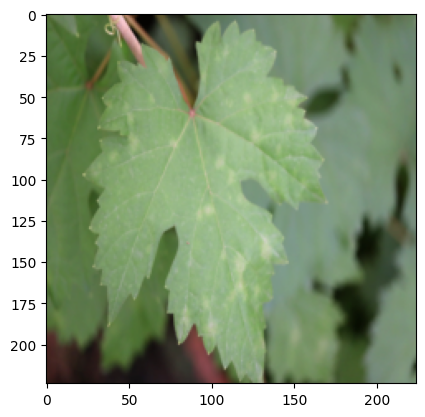

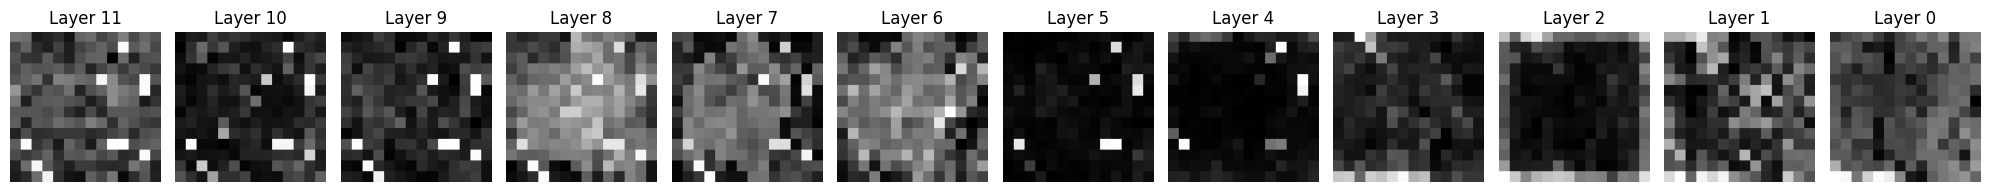

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def get_attention_map(attentions, layer_idx=-1, head_idx=0, average_heads=True):
    # Get attention weights from a specific layer
    attn_map = attentions[layer_idx][0].detach().cpu().numpy()
    
    if average_heads:
        # Average over all heads
        attn_map = attn_map.mean(axis=0)
    else:
        # Select a specific head
        attn_map = attn_map[head_idx]
    
    # Remove attention to [CLS] token and reshape
    attn_map = attn_map[1:, 1:]
    attn_map = attn_map.reshape(14, 14, 14, 14)
    
    # Average attention across patch dimensions
    attn_map = attn_map.mean(axis=(2, 3))
    
    return attn_map

def plot_attention(image, attention_map, alpha=0.6):
    # Resize attention map to match image size
    attention_map = Image.fromarray(attention_map).resize(image.size, Image.NEAREST)
    attention_map = np.array(attention_map)
    
    # Normalize attention map
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    
    # Create color map
    cmap = plt.get_cmap('Grays')
    attention_map_color = cmap(attention_map)
    
    # Convert image to numpy array
    image_np = np.array(image)
    
    # Overlay attention map on image
    overlay = image_np * (1 - alpha) + attention_map_color[:, :, :3] * alpha * 255
    
    return overlay.astype(np.uint8)

# Process the sample image
sample = next(iter(dataloader))
pixel_values = sample['pixel_values']
outputs = model(pixel_values, output_attentions=True)
attentions = outputs.attentions

# Convert the image tensor to a PIL Image
image = pixel_values[0].permute(1, 2, 0).cpu().numpy()
image = (image - image.min()) / (image.max()-image.min())
image = (image * 255).astype(np.uint8)
image = Image.fromarray(image)

# Get attention map for the last layer, averaged over all heads
attn_map = get_attention_map(attentions, layer_idx=1, average_heads=True)

# Plot the attention overlay
overlay = plot_attention(image, attn_map)

# Display the result
# fig, axis = plt.subplots(1,2, figsize=(8,8))
# axis[0].imshow(overlay)
# axis[0].axis('off')
# axis[0].set_title("Attention Visualization (Averaged over all heads)")
# axis[1].imshow(image)
# plt.show()

plt.imshow(image)

# Optional: You can also create a function to visualize multiple layers
def visualize_multiple_layers(image, attentions, num_layers=4):
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 5))
    for i in range(num_layers):
        layer_idx = -(i+1)  # Start from the last layer
        attn_map = get_attention_map(attentions, layer_idx=layer_idx, average_heads=True)
        overlay = plot_attention(image, attn_map, alpha=1)
        axes[i].imshow(overlay)
        axes[i].axis('off')
        axes[i].set_title(f"Layer {len(attentions) + layer_idx}")
    plt.tight_layout()
    plt.show()
# print("Labels: ", sample['labels'])
visualize_multiple_layers(image, attentions, num_layers=12)

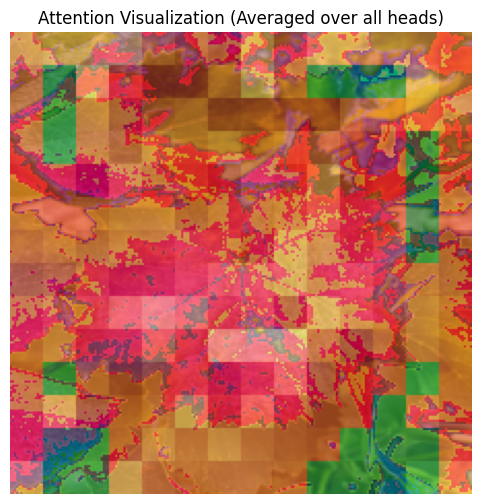

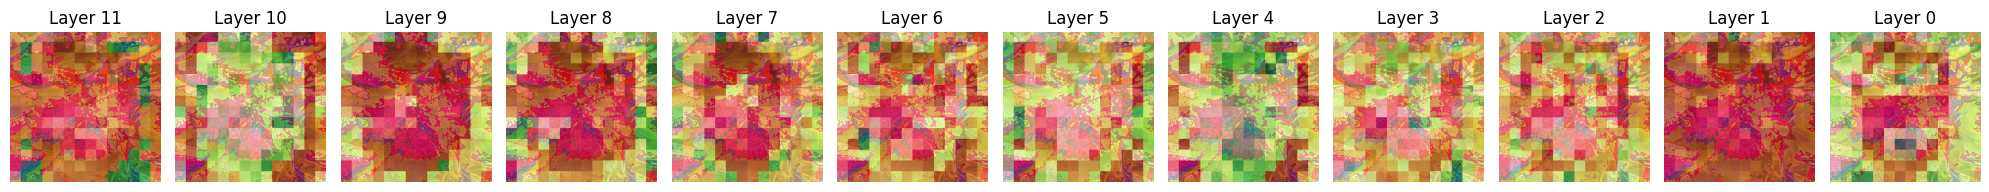

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

def get_attention_map(attentions, layer_idx=-1, average_heads=True):
    # Get attention weights from a specific layer
    attn_map = attentions[layer_idx][0].detach().cpu().numpy()
    
    if average_heads:
        # Average over all heads
        attn_map = attn_map.min(axis=0)
    else:
        # If not averaging, just take the first head
        attn_map = attn_map[0]
    
    # Remove attention to [CLS] token and reshape
    attn_map = attn_map[1:, 1:]
    attn_map = attn_map.reshape(14, 14, 14, 14)
    
    # Average attention across patch dimensions
    attn_map = attn_map.mean(axis=(2, 3))
    
    return attn_map

def plot_attention(image, attention_map, alpha=0.6):
    # Resize attention map to match image size
    attention_map = Image.fromarray(attention_map).resize(image.size, Image.NEAREST)
    attention_map = np.array(attention_map)
    
    # Normalize attention map
    attention_map = (attention_map - attention_map.min()) / (attention_map.max() - attention_map.min())
    
    # Create color map
    cmap = plt.get_cmap('RdYlGn')
    attention_map_color = cmap(attention_map)
    
    # Convert image to numpy array
    image_np = np.array(image)
    
    # Overlay attention map on image
    overlay = image_np * (1 - alpha) + attention_map_color[:, :, :3] * alpha * 255
    
    return overlay.astype(np.uint8)

# Process the sample image
image = sample['pixel_values'][0].permute(1, 2, 0).cpu().numpy()
image = (image * 255).astype(np.uint8)
image = Image.fromarray(image)

# Get attention weights
attentions = preds.attentions

# Get attention map for the last layer, averaged over all heads
attn_map = get_attention_map(attentions, layer_idx=-1, average_heads=True)

# Plot the attention overlay
overlay = plot_attention(image, attn_map)

# Display the result
plt.figure(figsize=(6, 6))
plt.imshow(overlay)
plt.axis('off')
plt.title("Attention Visualization (Averaged over all heads)")
plt.show()

# Optional: You can also create a function to visualize multiple layers
def visualize_multiple_layers(image, attentions, num_layers=4):
    fig, axes = plt.subplots(1, num_layers, figsize=(20, 5))
    for i in range(num_layers):
        layer_idx = -(i+1)  # Start from the last layer
        attn_map = get_attention_map(attentions, layer_idx=layer_idx, average_heads=True)
        overlay = plot_attention(image, attn_map)
        axes[i].imshow(overlay)
        axes[i].axis('off')
        axes[i].set_title(f"Layer {len(attentions) + layer_idx}")
    plt.tight_layout()
    plt.show()

# Uncomment the following line to visualize multiple layers
visualize_multiple_layers(image, attentions, num_layers=12)

In [109]:
model.state_dict().keys()

odict_keys(['vit.embeddings.cls_token', 'vit.embeddings.position_embeddings', 'vit.embeddings.patch_embeddings.projection.weight', 'vit.embeddings.patch_embeddings.projection.bias', 'vit.encoder.layer.0.attention.attention.query.weight', 'vit.encoder.layer.0.attention.attention.query.bias', 'vit.encoder.layer.0.attention.attention.key.weight', 'vit.encoder.layer.0.attention.attention.key.bias', 'vit.encoder.layer.0.attention.attention.value.weight', 'vit.encoder.layer.0.attention.attention.value.bias', 'vit.encoder.layer.0.attention.output.dense.weight', 'vit.encoder.layer.0.attention.output.dense.bias', 'vit.encoder.layer.0.intermediate.dense.weight', 'vit.encoder.layer.0.intermediate.dense.bias', 'vit.encoder.layer.0.output.dense.weight', 'vit.encoder.layer.0.output.dense.bias', 'vit.encoder.layer.0.layernorm_before.weight', 'vit.encoder.layer.0.layernorm_before.bias', 'vit.encoder.layer.0.layernorm_after.weight', 'vit.encoder.layer.0.layernorm_after.bias', 'vit.encoder.layer.1.atten

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(preds.attentions[6].squeeze().min(axis=0).values.detach(), cmap="gray")